In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
data_folder = '../data/raw/'
output_folder = '../data/processed/'

In [3]:
# Data downloaded from https://www.entsoe.eu/data/power-stats/ - Monthly Hourly Load Values - Aggregated hourly load by country
os.listdir(data_folder)

['monthly_hourly_load_values_2019.csv',
 'monthly_hourly_load_values_2025.csv',
 'monthly_hourly_load_values_2024.csv',
 'Monthly-hourly-load-values_2006-2015.xlsx',
 'monthly_hourly_load_values_2023.csv',
 'monthly_hourly_load_values_2022.csv',
 'monthly_hourly_load_values_2020.csv',
 'monthly_hourly_load_values_2021.csv',
 'MHLV_data-2015-2019.xlsx']

In [4]:
def make_index(df, date_col='DateUTC'):
    """ Function to make a datetime index from the DateUTC column, which has a changing format across files. """
    # Handle the date column with changing format
    df[date_col] = df[date_col].replace('/', '-', regex=True)
    
    # Set index to DateUTC and convert to datetime
    df.set_index(date_col, inplace=True)
    df.index = pd.to_datetime(df.index, format='%d-%m-%Y %H:%M')
    return df

In [5]:
def process_csv(file_path):
    """  Function to read and process a single CSV. """
    df = pd.read_csv(file_path, delimiter=r'[\t;]', engine='python')

    # Focus on NL for now
    df = df.loc[df['CountryCode'] == 'NL']
    
    # Cleanup the DateShort column so it's all one format
    df['DateShort'] = df['DateShort'].replace('/', '-', regex=True)

    # Cleanup the TimeFrom column so it's all one format
    df['TimeFrom'] = df['TimeFrom'].map(lambda x: x[:5])

    # Combine DateShort and TimeFrom to create a proper datetime index - some files have issues with the DateUTC column being off by 1 timestep
    df['CorrectedDateUTC'] = pd.to_datetime(df['DateShort'] + ' ' + df['TimeFrom'], format='%d-%m-%Y %H:%M')
    df = make_index(df, 'CorrectedDateUTC')
    
    # Drop redundant columns and rename columns for clarity
    df.drop(columns=['MeasureItem', 'DateUTC', 'DateShort', 'TimeFrom', 'TimeTo', 'CountryCode', 'Cov_ratio', 'Value', 'CreateDate', 'UpdateDate'], inplace=True, errors='ignore')
    df.rename(columns={'Value_ScaleTo100': 'Load'}, inplace=True)
    df.rename_axis('DateUTC', inplace=True)
    return df



In [6]:
# Process the more recent files
df_list = []
for year in range(2019,2026):
    df = process_csv(os.path.join(data_folder, f'monthly_hourly_load_values_{year}.csv'))
    df_list.append(df)

In [7]:
# Open and process the 2006-2015 xlsx file
df = pd.read_excel(os.path.join(data_folder, 'Monthly-hourly-load-values_2006-2015.xlsx'), skiprows=3)

# Reshape the data and add a new index
df_melted = pd.melt(df, id_vars=['Country', 'Year', 'Month', 'Day', 'Coverage ratio'], value_vars=[i for i in range(0,24)], var_name='Hour', value_name='Load')
df_melted['DateUTC'] = pd.to_datetime(df_melted['Day'].astype(str) + '-' + df_melted['Month'].astype(str) + '-' + df_melted['Year'].astype(str) +
                                               ' ' + df_melted['Hour'].astype(str) + ':00', format='%d-%m-%Y %H:%M')

# Select only NL
df = df_melted[df_melted['Country'] == 'NL'].copy()
df.set_index('DateUTC', inplace=True)
df.drop(columns=['Country', 'Year', 'Month', 'Day', 'Coverage ratio', 'Hour'], inplace=True)

# Add the 2006-2015 data to the list of dataframes
df_list.append(df)

In [8]:
# Open and process the 2015-2019 xlsx file
df = pd.read_excel(os.path.join(data_folder, 'MHLV_data-2015-2019.xlsx'))

# Focus on NL for now
df = df.loc[df['CountryCode'] == 'NL']

# Cleanup the DateShort column so it's all one format
df['DateShort'] = df['DateShort'].replace('/', '-', regex=True)

# Cleanup the TimeFrom column so it's all one format
df['TimeFrom'] = df['TimeFrom'].astype(str).str[:5]#df['TimeFrom'].map(lambda x: x[:5])

# Combine DateShort and TimeFrom to create a proper datetime index - some files have issues with the DateUTC column being off by 1 timestep
df['CorrectedDateUTC'] = pd.to_datetime(df['DateShort'].astype(str) + ' ' + df['TimeFrom'], format='%Y-%m-%d %H:%M')
df = make_index(df, 'CorrectedDateUTC')

# Drop redundant columns and rename columns for clarity
df.drop(columns=['MeasureItem', 'DateUTC', 'DateShort', 'TimeFrom', 'TimeTo', 'CountryCode', 'Cov_ratio', 'Value', 'CreateDate', 'UpdateDate'], inplace=True, errors='ignore')
df.rename(columns={'Value_ScaleTo100': 'Load'}, inplace=True)
df.rename_axis('DateUTC', inplace=True)

df_list.append(df)

In [9]:
# Combine all dataframes into one, sort by index
df_all = pd.concat(df_list)
df_all.sort_index(inplace=True)

In [10]:
# Check for duplicates
df_all.index[np.where(df_all.index.duplicated())]

DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='DateUTC', freq=None)

In [11]:
df_all.loc['2015-12-31 22:00':'2016-01-01 00:00']

,Load
DateUTC,
2015-12-31 22:00:00,11772.0
2015-12-31 23:00:00,11563.0
2015-12-31 23:00:00,11373.0
2016-01-01 00:00:00,11102.0


In [12]:
"""
Strangely there are two values for 2015-12-31 23:00:00, we will use the 11373 value
because it comes from the 2015-2019 file, likely a more accurate value
"""

df_all = df_all.loc[~df_all.index.duplicated(keep='last'), :]

In [13]:
# Sanity check
df_all.loc['2015-12-31 22:00':'2016-01-01 00:00']

,Load
DateUTC,
2015-12-31 22:00:00,11772.0
2015-12-31 23:00:00,11373.0
2016-01-01 00:00:00,11102.0


<Axes: title={'center': 'Hourly Load in the Netherlands (2006-2025)'}, xlabel='DateUTC'>

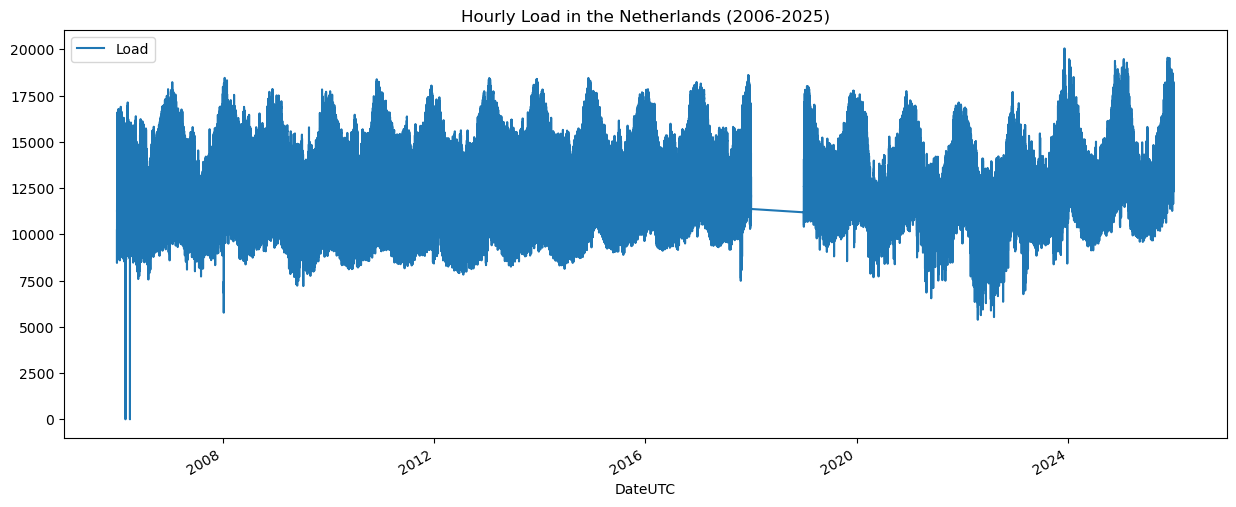

In [14]:
# Plot the data to check for any obvious issues
df_all.plot.line(figsize=(15, 6), title='Hourly Load in the Netherlands (2006-2025)')

In [15]:
# Strangely also, the 2018 data is missing! Plus, there are some outliers, but we can handle that in the modelling stage
df_all.loc['2017-12-31 23:00':'2019-01-01 00:00']

,Load
DateUTC,
2017-12-31 23:00:00,11375.000
2019-01-01 00:00:00,11193.635


In [16]:
# Save the processed data to a new CSV file
df_all.to_csv(os.path.join(output_folder, 'NL_hourly_load_2006-2025_missing_2018.csv'))